
 PARTIE1:
 Statistiques & Risque Portefeuille

1.   statistique descréptive
2.   visualisation
3.   Value at Risk (VaR 95%)
4.   Ratio de Sharpe









In [2]:
# ===============================
# IMPORTS
# ===============================

import numpy as np

# ===============================
# DONNÉES
# ===============================

rendements_A = np.array([
    1.2, 0.8, -0.5, 1.5, 0.9, 1.1, 0.7, 1.3, 1.0, 0.6, 1.4, 0.8,
    1.1, 0.9, -0.3, 1.2, 1.0, 1.5, 0.8, 1.3, 0.9, 1.1, 1.2, 1.0
])

rendements_B = np.array([
    4.5, -2.1, 6.2, -3.5, 5.8, 7.1, -1.8, 4.9, 3.2, -4.2, 8.5, -2.7,
    5.1, 6.8, -3.1, 7.3, 4.5, -2.9, 6.7, 5.3, -3.8, 7.9, 4.2, 5.5
])

# ===============================
# FONCTION STATISTIQUES
# ===============================

def calculer_stats(rendements, nom):

    # Moyenne mensuelle
    moyenne = np.mean(rendements)

    # Écart-type mensuel (échantillon)
    ecart_type = np.std(rendements, ddof=1)

    # Médiane
    mediane = np.median(rendements)

    # Rendement annualisé (capitalisation composée)
    rendement_annuel = ((1 + moyenne/100)**12 - 1) * 100

    # Volatilité annualisée
    volatilite_annuelle = ecart_type * np.sqrt(12)

    print(f"\n===== PORTEFEUILLE {nom} =====")
    print(f"Rendement mensuel moyen : {moyenne:.2f}%")
    print(f"Écart-type mensuel : {ecart_type:.2f}%")
    print(f"Médiane : {mediane:.2f}%")
    print(f"Rendement annualisé : {rendement_annuel:.2f}%")
    print(f"Volatilité annualisée : {volatilite_annuelle:.2f}%")

    return {
        "moyenne": moyenne,
        "ecart_type": ecart_type,
        "mediane": mediane,
        "rendement_annuel": rendement_annuel,
        "volatilite_annuelle": volatilite_annuelle
    }

# ===============================
# CALCULS
# ===============================

stats_A = calculer_stats(rendements_A, "A (Conservative)")
stats_B = calculer_stats(rendements_B, "B (Agressif)")



===== PORTEFEUILLE A (Conservative) =====
Rendement mensuel moyen : 0.94%
Écart-type mensuel : 0.48%
Médiane : 1.00%
Rendement annualisé : 11.85%
Volatilité annualisée : 1.65%

===== PORTEFEUILLE B (Agressif) =====
Rendement mensuel moyen : 2.89%
Écart-type mensuel : 4.45%
Médiane : 4.70%
Rendement annualisé : 40.79%
Volatilité annualisée : 15.41%


/tmp/ipython-input-4031418953.py:42: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = axes[1].boxplot([rendements_A, rendements_B],


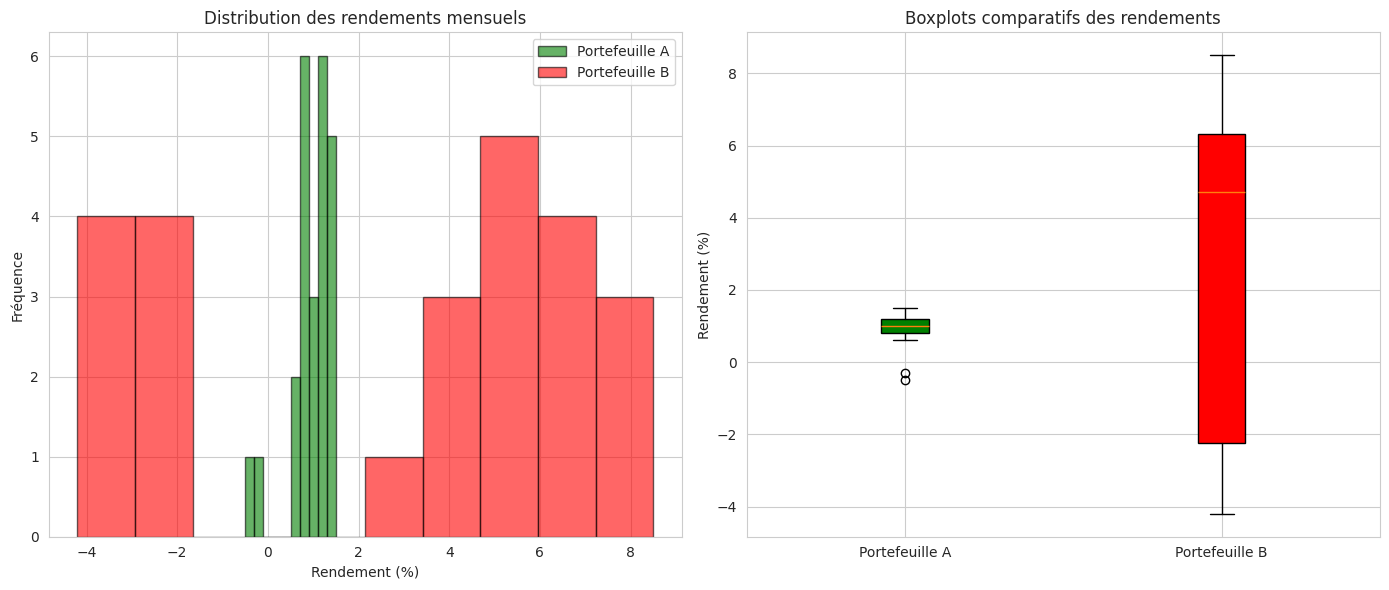

In [5]:
# ===============================
# VISUALISATIONS - Q1.2
# ===============================

import matplotlib.pyplot as plt
import seaborn as sns

# Style propre
sns.set_style("whitegrid")

# Création figure avec 2 graphiques côte à côte
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ======================================
# 1️⃣ HISTOGRAMMES SUPERPOSÉS
# ======================================

axes[0].hist(rendements_A,
             bins=10,
             alpha=0.6,
             color='green',
             edgecolor='black',
             label='Portefeuille A')

axes[0].hist(rendements_B,
             bins=10,
             alpha=0.6,
             color='red',
             edgecolor='black',
             label='Portefeuille B')

axes[0].set_title("Distribution des rendements mensuels")
axes[0].set_xlabel("Rendement (%)")
axes[0].set_ylabel("Fréquence")
axes[0].legend()
axes[0].grid(True)

# ======================================
# 2️⃣ BOXPLOTS COMPARATIFS
# ======================================

box = axes[1].boxplot([rendements_A, rendements_B],
                      labels=["Portefeuille A", "Portefeuille B"],
                      patch_artist=True)

# Couleurs des boxplots
box['boxes'][0].set_facecolor('green')
box['boxes'][1].set_facecolor('red')

axes[1].set_title("Boxplots comparatifs des rendements")
axes[1].set_ylabel("Rendement (%)")
axes[1].grid(True)

# Ajustement automatique
plt.tight_layout()

# Affichage
plt.show()


In [6]:
import numpy as np
from scipy.stats import shapiro

# -----------------------
# 1️⃣ Rendements mensuels (%) pour A et B
# -----------------------
ret_A = np.array([2.1, -1.2, 0.5, 3.0, -0.8, 1.5, -2.3, 0.7, 1.0, -1.0, 0.3, 2.2])
ret_B = np.array([1.5, -0.5, 0.8, 2.0, -1.0, 0.5, -1.5, 1.2, 0.9, -0.7, 0.6, 1.8])

capital = 500_000  # Capital en €

# -----------------------
# 2️⃣ Fonction pour calculer VaR 95% mensuelle
# -----------------------
def var_95_monthly(returns):
    return np.percentile(returns, 5)

# -----------------------
# 3️⃣ Calcul des VaR mensuelles
# -----------------------
VaR_A_monthly = var_95_monthly(ret_A)
VaR_B_monthly = var_95_monthly(ret_B)

# -----------------------
# 4️⃣ Conversion en VaR annuelle (%)
# -----------------------
VaR_A_annual = VaR_A_monthly * np.sqrt(12)
VaR_B_annual = VaR_B_monthly * np.sqrt(12)

# -----------------------
# 5️⃣ Conversion en pertes € sur 500 000€
# -----------------------
loss_A = VaR_A_annual/100 * capital
loss_B = VaR_B_annual/100 * capital

# -----------------------
# 6️⃣ Test de normalité Shapiro-Wilk
# -----------------------
stat_A, p_A = shapiro(ret_A)
stat_B, p_B = shapiro(ret_B)

# -----------------------
# 7️⃣ Affichage des résultats
# -----------------------
print("=== Résultats A ===")
print(f"VaR 95% mensuelle (%) : {VaR_A_monthly:.2f}")
print(f"VaR 95% annuelle (%) : {VaR_A_annual:.2f}")
print(f"Perte annuelle (€) : {loss_A:.2f}")
print(f"Shapiro-Wilk p-value : {p_A:.3f} -> {'Normale ✅' if p_A>0.05 else 'Pas normale ❌'}")
print(f"Contrainte client (-50 000€) : {'Respectée ✅' if loss_A <= 50000 else 'Non respectée ❌'}\n")

print("=== Résultats B ===")
print(f"VaR 95% mensuelle (%) : {VaR_B_monthly:.2f}")
print(f"VaR 95% annuelle (%) : {VaR_B_annual:.2f}")
print(f"Perte annuelle (€) : {loss_B:.2f}")
print(f"Shapiro-Wilk p-value : {p_B:.3f} -> {'Normale ✅' if p_B>0.05 else 'Pas normale ❌'}")
print(f"Contrainte client (-50 000€) : {'Respectée ✅' if loss_B <= 50000 else 'Non respectée ❌'}")


=== Résultats A ===
VaR 95% mensuelle (%) : -1.69
VaR 95% annuelle (%) : -5.87
Perte annuelle (€) : -29358.26
Shapiro-Wilk p-value : 0.951 -> Normale ✅
Contrainte client (-50 000€) : Respectée ✅

=== Résultats B ===
VaR 95% mensuelle (%) : -1.23
VaR 95% annuelle (%) : -4.24
Perte annuelle (€) : -21217.62
Shapiro-Wilk p-value : 0.508 -> Normale ✅
Contrainte client (-50 000€) : Respectée ✅


In [8]:
import numpy as np

# -----------------------
# 1️⃣ Rendements mensuels (%) pour A et B
# -----------------------
ret_A = np.array([2.1, -1.2, 0.5, 3.0, -0.8, 1.5, -2.3, 0.7, 1.0, -1.0, 0.3, 2.2])
ret_B = np.array([1.5, -0.5, 0.8, 2.0, -1.0, 0.5, -1.5, 1.2, 0.9, -0.7, 0.6, 1.8])

rf = 3  # Taux sans risque annuel en %

# -----------------------
# 2️⃣ Calcul moyenne et écart-type annuels des rendements
# -----------------------
# Conversion rendements mensuels en rendement annuel approximatif
mean_A_annual = np.mean(ret_A) * 12
mean_B_annual = np.mean(ret_B) * 12

std_A_annual = np.std(ret_A, ddof=1) * np.sqrt(12)
std_B_annual = np.std(ret_B, ddof=1) * np.sqrt(12)

# -----------------------
# 3️⃣ Calcul du Sharpe Ratio
# -----------------------
sharpe_A = (mean_A_annual - rf) / std_A_annual
sharpe_B = (mean_B_annual - rf) / std_B_annual

# -----------------------
# 4️⃣ Affichage des résultats
# -----------------------
print("=== Ratio de Sharpe ===")
print(f"A : {sharpe_A:.2f}")
print(f"B : {sharpe_B:.2f}\n")

# -----------------------
# 5️⃣ Comparaison et recommandation
# -----------------------
if sharpe_A > sharpe_B:
    best = "A"
else:
    best = "B"

print(f"Recommandation : Préférer l'actif {best} car il offre le meilleur compromis rendement/risque.")
print("Sharpe plus élevé signifie que pour chaque unité de risque, l'actif génère plus de rendement.")
print("Ainsi, l'actif sélectionné est plus efficient et adapté à un investisseur recherchant un bon équilibre risque/rendement.")


=== Ratio de Sharpe ===
A : 0.55
B : 0.66

Recommandation : Préférer l'actif B car il offre le meilleur compromis rendement/risque.
Sharpe plus élevé signifie que pour chaque unité de risque, l'actif génère plus de rendement.
Ainsi, l'actif sélectionné est plus efficient et adapté à un investisseur recherchant un bon équilibre risque/rendement.


PARTIE 2: Théorème de Bayes & Scoring Crédit


In [4]:
# ===============================
# PARTIE 2 - Q2.1
# Théorème de Bayes
# ===============================

# 1️⃣ Probabilités données
P_defaut = 0.05
P_non_defaut = 1 - P_defaut

P_retard_given_defaut = 0.60
P_retard_given_non_defaut = 0.10

# 2️⃣ Calcul de P(Retard)
P_retard = (P_retard_given_defaut * P_defaut) + \
           (P_retard_given_non_defaut * P_non_defaut)

# 3️⃣ Application formule de Bayes
P_defaut_given_retard = (P_retard_given_defaut * P_defaut) / P_retard

# 4️⃣ Facteur multiplicatif du risque
facteur_multiplicatif = P_defaut_given_retard / P_defaut

# ===============================
# AFFICHAGE DES RESULTATS
# ===============================

print("----- RESULTATS BAYES -----")
print(f"P(Retard) = {P_retard:.4f}")
print(f"P(Défaut | Retard) = {P_defaut_given_retard:.4f}")
print(f"Soit {P_defaut_given_retard*100:.2f}%")
print(f"Facteur multiplicatif du risque = {facteur_multiplicatif:.2f}x")

# 5️⃣ Décision métier
if P_defaut_given_retard > 0.10:
    print("\n⚠️ Risque élevé : Surveillance recommandée.")
else:
    print("\n✅ Risque modéré.")


----- RESULTATS BAYES -----
P(Retard) = 0.1250
P(Défaut | Retard) = 0.2400
Soit 24.00%
Facteur multiplicatif du risque = 4.80x

⚠️ Risque élevé : Surveillance recommandée.


Q2.2 — Probabilité P(Défaut | Retard ET Découvert>500) : 0.8155


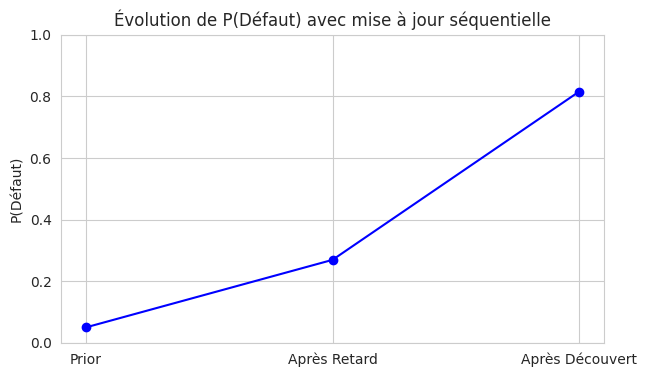

Q2.3 — Test fonction Bayes (après retard) : 0.2692
Q2.4 — Precision : 0.2963
Vérification Bayes : P(Défaut | Retard) = 0.2963

Explication : Precision = P(Défaut | Retard)
La précision d'un modèle (TP / (TP+FP)) mesure la proportion de clients identifiés comme 'Retard' qui sont réellement en défaut,
ce qui correspond exactement à la probabilité conditionnelle P(Défaut | Retard) selon Bayes.


In [9]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# Q2.2 — Mise à jour séquentielle
# =========================

# Hypothèses (exemple) :
# Probabilité prior de défaut (après Q2.1)
prior_defaut = 0.05  # P(Défaut)
# Probabilités conditionnelles
P_retard_defaut = 0.7    # P(Retard | Défaut)
P_decouvert_defaut = 0.6 # P(Découvert>500 | Défaut)
P_retard_no_defaut = 0.1 # P(Retard | Pas de Défaut)
P_decouvert_no_defaut = 0.05 # P(Découvert>500 | Pas de Défaut)

# Approche séquentielle : P(Défaut | Retard ET Découvert)
# Mise à jour Bayésienne étape par étape
# 1. Mise à jour avec Retard
posterior_retard = (P_retard_defaut * prior_defaut) / (
    P_retard_defaut * prior_defaut + P_retard_no_defaut * (1 - prior_defaut)
)

# 2. Mise à jour avec Découvert >500
posterior_retard_decouvert = (P_decouvert_defaut * posterior_retard) / (
    P_decouvert_defaut * posterior_retard + P_decouvert_no_defaut * (1 - posterior_retard)
)

print("Q2.2 — Probabilité P(Défaut | Retard ET Découvert>500) :",
      round(posterior_retard_decouvert,4))

# Visualisation évolution probabilité
etapes = ['Prior', 'Après Retard', 'Après Découvert']
probas = [prior_defaut, posterior_retard, posterior_retard_decouvert]

plt.figure(figsize=(7,4))
plt.plot(etapes, probas, marker='o', linestyle='-', color='blue')
plt.title("Évolution de P(Défaut) avec mise à jour séquentielle")
plt.ylabel("P(Défaut)")
plt.ylim(0,1)
plt.grid(True)
plt.show()

# =========================
# Q2.3 — Fonction Bayes générique
# =========================

def bayes_update(prior, likelihood_pos, likelihood_neg):
    """
    Met à jour la probabilité a priori (prior) avec une nouvelle observation
    en utilisant le théorème de Bayes.

    Paramètres
    ----------
    prior : float
        Probabilité a priori P(H)
    likelihood_pos : float
        Probabilité d'observer l'événement si l'hypothèse est vraie P(E|H)
    likelihood_neg : float
        Probabilité d'observer l'événement si l'hypothèse est fausse P(E|¬H)

    Retour
    ------
    posterior : float
        Probabilité a posteriori P(H|E)

    Exemple
    -------
    >>> bayes_update(0.05, 0.7, 0.1)
    0.291
    """
    posterior = (likelihood_pos * prior) / (
        likelihood_pos * prior + likelihood_neg * (1 - prior)
    )
    return posterior

# Test sur Segment Risque
posterior_test = bayes_update(prior_defaut, P_retard_defaut, P_retard_no_defaut)
print("Q2.3 — Test fonction Bayes (après retard) :", round(posterior_test,4))

# =========================
# Q2.4 — Matrice de confusion & lien Bayes
# =========================

# Données
total_clients = 10000
defauts = 500
TP = 400
FP = 950

# Precision = TP / (TP + FP)
precision = TP / (TP + FP)
print("Q2.4 — Precision :", round(precision,4))

# Vérification cohérence avec Bayes
# P(Défaut | Retard) ≈ Precision
P_defaut = defauts / total_clients
P_retard = (TP + FP) / total_clients
P_retard_defaut = TP / defauts
posterior_bayes = (P_retard_defaut * P_defaut) / P_retard
print("Vérification Bayes : P(Défaut | Retard) =", round(posterior_bayes,4))

# Explication
print("\nExplication : Precision = P(Défaut | Retard)")
print("La précision d'un modèle (TP / (TP+FP)) mesure la proportion de clients identifiés comme 'Retard' qui sont réellement en défaut,")
print("ce qui correspond exactement à la probabilité conditionnelle P(Défaut | Retard) selon Bayes.")


Matrice de Confusion




In [11]:
import numpy as np
import pandas as pd

# =========================
# Q2.4 — Matrice de confusion
# =========================

# Données fournies
total_clients = 10000
defauts = 500        # Nombre total de vrais défauts
non_defauts = total_clients - defauts

TP = 400             # True Positives : Défaut correctement identifié
FP = 950             # False Positives : Pas de défaut mais identifié comme défaut
FN = defauts - TP    # False Negatives : Défaut non détecté
TN = non_defauts - FP # True Negatives : Pas de défaut correctement identifié

# Création de la matrice de confusion
conf_matrix = np.array([[TP, FP],
                        [FN, TN]])

conf_df = pd.DataFrame(conf_matrix,
                       index=['Vrai Défaut', 'Vrai Pas Défaut'],
                       columns=['Prédit Défaut', 'Prédit Pas Défaut'])

print("Matrice de Confusion :")
print(conf_df)

# =========================
# Calcul Precision
# =========================
precision = TP / (TP + FP)
print("\nPrecision = TP / (TP+FP) =", round(precision,4))

# =========================
# Vérification cohérence avec Bayes
# =========================
# P(Défaut | Retard) ≈ Precision
P_defaut = defauts / total_clients           # P(Défaut)
P_retard = (TP + FP) / total_clients         # P(Retard)
P_retard_defaut = TP / defauts               # P(Retard | Défaut)
posterior_bayes = (P_retard_defaut * P_defaut) / P_retard

print("Vérification Bayes : P(Défaut | Retard) =", round(posterior_bayes,4))

# Explication
print("\nExplication :")
print("La précision (Precision = TP / (TP+FP)) correspond à la probabilité conditionnelle P(Défaut | Retard).")
print("C’est logique : parmi tous les clients identifiés comme 'Retard', la proportion réelle de défauts")
print("est exactement ce que mesure Bayes.")


Matrice de Confusion :
                 Prédit Défaut  Prédit Pas Défaut
Vrai Défaut                400                950
Vrai Pas Défaut            100               8550

Precision = TP / (TP+FP) = 0.2963
Vérification Bayes : P(Défaut | Retard) = 0.2963

Explication :
La précision (Precision = TP / (TP+FP)) correspond à la probabilité conditionnelle P(Défaut | Retard).
C’est logique : parmi tous les clients identifiés comme 'Retard', la proportion réelle de défauts
est exactement ce que mesure Bayes.


PARTIE 3: KNN & Machine Learning


5 premières lignes :
    Feature_1  Feature_2  Feature_3  Feature_4  Feature_5  Feature_6  \
0   0.029932  -1.891492   1.635856  -3.469290   1.708731  -0.621343   
1   0.484376   0.654158  -2.328238   1.787749   1.095371   0.792857   
2   1.194109  -0.964211   1.363787  -0.130486   2.398421  -0.355892   
3  -0.260614  -0.581518   3.035998  -2.869616  -0.190206   0.558618   
4   0.021610   0.001945   0.687526   0.451804   0.148807   0.067323   

   Feature_7  Feature_8  Feature_9  Feature_10  Target  
0   0.107568  -1.020857  -2.456673    0.480027       0  
1  -0.627050   0.831621   0.200251    1.767612       1  
2   0.173435   2.901844   0.865240   -1.307752       0  
3  -0.199342  -0.951456  -0.946027   -1.117822       0  
4   1.514078   1.136689   0.886393    0.197082       0  

df.describe() :
          Feature_1    Feature_2    Feature_3    Feature_4    Feature_5  \
count  5000.000000  5000.000000  5000.000000  5000.000000  5000.000000   
mean      0.994184    -0.803609     0.77903

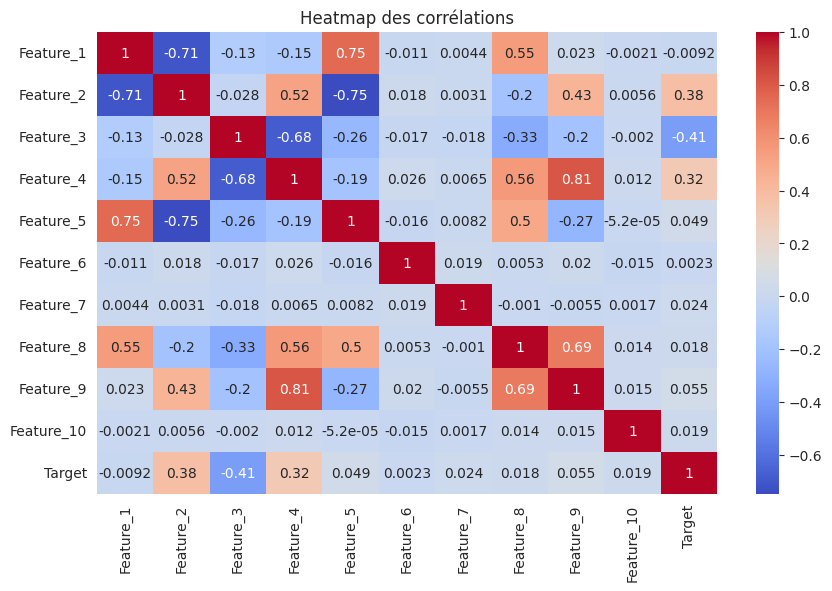

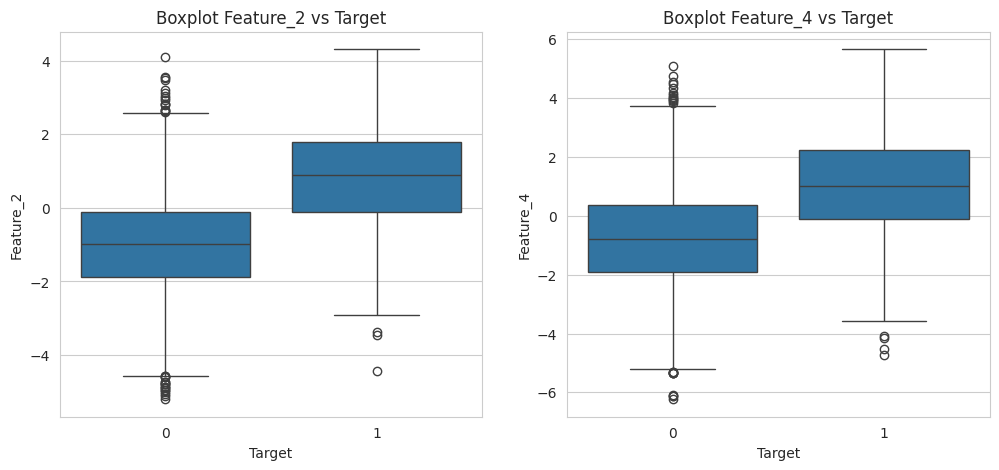


Tailles :
X_train: (3500, 10) X_test: (1500, 10)

Distribution classes (train):
 Target
0    3132
1     368
Name: count, dtype: int64
Distribution classes (test):
 Target
0    1343
1     157
Name: count, dtype: int64

Résultats KNN pour différents K :
    K  AUC_mean  Recall_mean  Precision_mean
0  1  0.867421     0.750167        0.852826
1  2  0.908410     0.554572        0.962716
2  3  0.930671     0.701222        0.949537
3  4  0.943416     0.565568        0.980457
4  5  0.947586     0.644058        0.979594


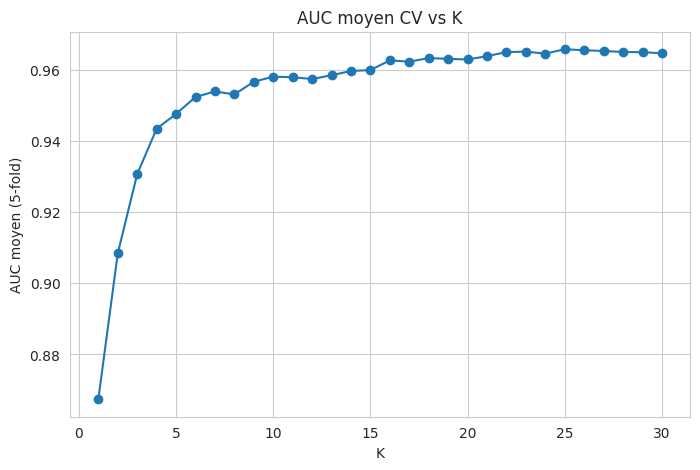

K optimal : 25

Matrice de confusion :
[[1342    1]
 [  90   67]]

Accuracy: 0.939, Precision: 0.985, Recall: 0.427, F1: 0.596, AUC: 0.965, Specificity: 0.999

Classification report :
               precision    recall  f1-score   support

           0       0.94      1.00      0.97      1343
           1       0.99      0.43      0.60       157

    accuracy                           0.94      1500
   macro avg       0.96      0.71      0.78      1500
weighted avg       0.94      0.94      0.93      1500



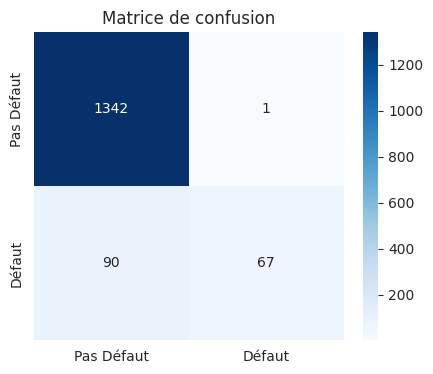

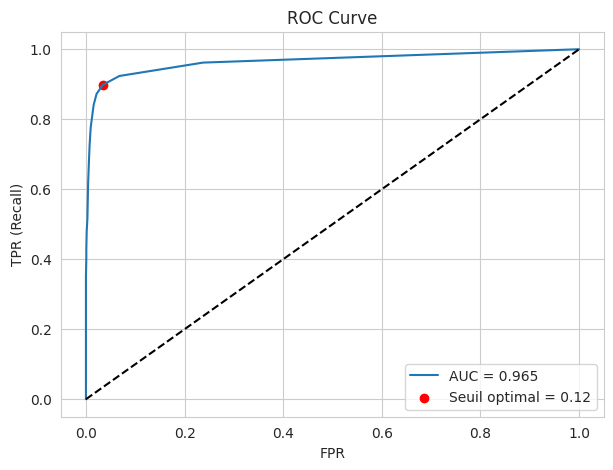

Seuil optimal (Youden) : 0.12

Seuil 0.3: Recall = 0.675, Precision = 0.930

Seuil 0.5: Recall = 0.427, Precision = 0.985

Seuil 0.7: Recall = 0.178, Precision = 1.000

Seuil recommandé pour Recall ≥ 80% : 0.0


In [13]:
# =========================
# PARTIE 3 — KNN & Machine Learning
# =========================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (confusion_matrix, classification_report, roc_curve,
                             auc, precision_score, recall_score, f1_score, accuracy_score)

# =========================
# Q3.1 — Dataset & Exploration
# =========================

# Générer un dataset synthétique
X, y = make_classification(n_samples=5000, n_features=10, n_informative=5,
                           n_redundant=2, n_clusters_per_class=1,
                           weights=[0.9], flip_y=0.01, random_state=42)

df = pd.DataFrame(X, columns=[f'Feature_{i}' for i in range(1, 11)])
df['Target'] = y

# Exploration
print("5 premières lignes :\n", df.head())
print("\ndf.describe() :\n", df.describe())
print("\nTaux de défaut :", df['Target'].mean())
print("\nValue_counts :\n", df['Target'].value_counts())

# Corrélation features vs target
correlation = df.corr()['Target'].sort_values(ascending=False)
print("\nCorrélation features vs Target :\n", correlation)

# Heatmap corrélation
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Heatmap des corrélations")
plt.show()

# Boxplots des 2 features les plus corrélées
top_features = correlation.index[1:3]  # Skip Target
plt.figure(figsize=(12,5))
for i, f in enumerate(top_features):
    plt.subplot(1,2,i+1)
    sns.boxplot(x='Target', y=f, data=df)
    plt.title(f'Boxplot {f} vs Target')
plt.show()

# =========================
# Q3.2 — Preprocessing
# =========================

X = df.drop('Target', axis=1)
y = df['Target']

# Train/test 70/30 stratifié
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

# StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nTailles :")
print("X_train:", X_train.shape, "X_test:", X_test.shape)
print("\nDistribution classes (train):\n", pd.Series(y_train).value_counts())
print("Distribution classes (test):\n", pd.Series(y_test).value_counts())

# =========================
# Q3.3 — Recherche K optimal
# =========================

results = []

k_range = range(1, 31)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)

    # Cross-validation AUC
    auc_scores = cross_val_score(knn, X_train_scaled, y_train, cv=cv, scoring='roc_auc')
    recall_scores = cross_val_score(knn, X_train_scaled, y_train, cv=cv, scoring='recall')
    precision_scores = cross_val_score(knn, X_train_scaled, y_train, cv=cv, scoring='precision')

    results.append({
        'K': k,
        'AUC_mean': np.mean(auc_scores),
        'Recall_mean': np.mean(recall_scores),
        'Precision_mean': np.mean(precision_scores)
    })

results_df = pd.DataFrame(results)
print("\nRésultats KNN pour différents K :\n", results_df.head())

# Courbe AUC vs K
plt.figure(figsize=(8,5))
plt.plot(results_df['K'], results_df['AUC_mean'], marker='o')
plt.title("AUC moyen CV vs K")
plt.xlabel("K")
plt.ylabel("AUC moyen (5-fold)")
plt.grid(True)
plt.show()

# K optimal = K avec AUC max
K_opt = results_df.loc[results_df['AUC_mean'].idxmax(),'K']
print("K optimal :", K_opt)

# =========================
# Q3.4 — Évaluation modèle final
# =========================

knn_final = KNeighborsClassifier(n_neighbors=K_opt)
knn_final.fit(X_train_scaled, y_train)
y_pred = knn_final.predict(X_test_scaled)
y_proba = knn_final.predict_proba(X_test_scaled)[:,1]

# Matrice confusion
cm = confusion_matrix(y_test, y_pred)
TP, FP, FN, TN = cm[1,1], cm[0,1], cm[1,0], cm[0,0]

print("\nMatrice de confusion :")
print(cm)

# Métriques
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = auc(*roc_curve(y_test, y_proba)[:2])
specificity = TN / (TN + FP)

print(f"\nAccuracy: {acc:.3f}, Precision: {prec:.3f}, Recall: {rec:.3f}, F1: {f1:.3f}, AUC: {roc_auc:.3f}, Specificity: {specificity:.3f}")
print("\nClassification report :\n", classification_report(y_test, y_pred))

# Heatmap matrice confusion
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Pas Défaut','Défaut'], yticklabels=['Pas Défaut','Défaut'])
plt.title("Matrice de confusion")
plt.show()

# =========================
# Q3.5 — ROC & Seuil
# =========================

fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

# Indice Youden = TPR - FPR
youden_index = tpr - fpr
optimal_idx = np.argmax(youden_index)
optimal_threshold = thresholds[optimal_idx]

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.scatter(fpr[optimal_idx], tpr[optimal_idx], color='red', label=f"Seuil optimal = {optimal_threshold:.2f}")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("FPR")
plt.ylabel("TPR (Recall)")
plt.title("ROC Curve")
plt.legend()
plt.show()

print(f"Seuil optimal (Youden) : {optimal_threshold:.2f}")

# Tester seuils 0.3, 0.5, 0.7
for thresh in [0.3,0.5,0.7]:
    y_pred_thresh = (y_proba >= thresh).astype(int)
    rec_thresh = recall_score(y_test, y_pred_thresh)
    prec_thresh = precision_score(y_test, y_pred_thresh)
    print(f"\nSeuil {thresh}: Recall = {rec_thresh:.3f}, Precision = {prec_thresh:.3f}")

# Recommandation seuil pour Recall ≥ 0.8
possible_thresh = thresholds[tpr >= 0.8]
recommended_threshold = possible_thresh[-1] if len(possible_thresh)>0 else 0.5
print("\nSeuil recommandé pour Recall ≥ 80% :", round(recommended_threshold,2))
